In [1]:
import numpy as np
import math
from functools import lru_cache
from scipy.optimize import minimize
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

In [ ]:

# Your log-likelihood: must return a finite scalar (higher is better)
def log_likelihood(theta):
    # <-- use your existing function here
    raise NotImplementedError

# parameter meta
"""param_names = ["Mphi", "g", "si"]                 # names in order of theta
bounds = [(0.1, 1000.0), (1e-4, 1.0), (2.0, 3.0)] # (min, max) for each param
theta0 = np.array([5.5, 0.035, 2.85])             # a decent starting guess (MLE-ish)"""
param_names = ["norm", "si1", "si2", "E_break"]  # E_break = log10(E_break/GeV)
bounds = [(1, 4), (0,3), (2, 4), (4, 5)]
theta0 = np.array([2.13, 1.72, 2.839, 10**4.524])

# which two parameters to show in 2D panels (by index)
scan_pairs = [(0, 1), (0, 2), (1, 2)]  # (Mphi,g), (Mphi,si), (g,si)

# grid sizes for profiling (adjust to your budget)
grid_1d = 80
grid_2d = (60, 60)  # (nx, ny)

# multiple random restarts (for non-convex likelihoods)
n_restarts = 3

# =======================
# Helpers
# =======================
def _clip_to_bounds(x, bnds):
    return np.array([np.clip(v, lo, hi) for v, (lo, hi) in zip(x, bnds)])

def _random_start(bounds):
    u = np.random.rand(len(bounds))
    return np.array([lo + u[i]*(hi-lo) for i, (lo,hi) in enumerate(bounds)])

def _minimize_negloglike(theta_start, fixed_idx=None, fixed_vals=None):
    """Maximize logL by minimizing -logL, with some parameters fixed."""

    # Build mask for free params
    p = len(bounds)
    free_mask = np.ones(p, dtype=bool)
    if fixed_idx is not None:
        free_mask[fixed_idx] = False

    x0 = theta_start[free_mask]
    bnds = [bounds[i] for i in range(p) if free_mask[i]]

    def pack(x_free):
        theta = theta_start.copy()
        theta[free_mask] = x_free
        if fixed_idx is not None:
            theta[fixed_idx] = fixed_vals
        return _clip_to_bounds(theta, bounds)

    def fun(x_free):
        th = pack(x_free)
        val = log_likelihood(th)
        if not np.isfinite(val):
            return 1e300  # penalize invalid
        return -val

    res = minimize(fun, x0=x0, bounds=bnds, method="L-BFGS-B")
    th_hat = pack(res.x)
    return th_hat, -res.fun

def maximize_loglike_global():
    """Global MLE with multi-start."""
    best_ll = -np.inf
    best_th = None
    # try centered start + random restarts
    for _ in range(n_restarts+1):
        start = theta0 if _ == 0 else _random_start(bounds)
        th, ll = _minimize_negloglike(start)
        if ll > best_ll:
            best_ll, best_th = ll, th
    return best_th, best_ll

def profile_loglike_1d(j, grid=None):
    """Profile over all params except j; return thetas_j, ll_prof."""
    lo, hi = bounds[j]
    thetas = np.linspace(lo, hi, grid_1d) if grid is None else grid
    ll_prof = np.full_like(thetas, -np.inf, dtype=float)

    for k, val in enumerate(thetas):
        # fix θ_j = val, optimize others
        start = theta0.copy()
        start[j] = val
        th, ll = _minimize_negloglike(start, fixed_idx=[j], fixed_vals=[val])
        ll_prof[k] = ll
    return thetas, ll_prof

def profile_loglike_2d(a, b, grid_x=None, grid_y=None):
    """Profile over all params except (a,b). Return X, Y, ll_prof grid."""
    xlo, xhi = bounds[a]; ylo, yhi = bounds[b]
    xs = np.linspace(xlo, xhi, grid_2d[0]) if grid_x is None else grid_x
    ys = np.linspace(ylo, yhi, grid_2d[1]) if grid_y is None else grid_y

    LL = np.full((len(ys), len(xs)), -np.inf, dtype=float)
    for ix, xv in enumerate(xs):
        for iy, yv in enumerate(ys):
            start = theta0.copy()
            start[a] = xv; start[b] = yv
            th, ll = _minimize_negloglike(start, fixed_idx=[a,b], fixed_vals=[xv,yv])
            LL[iy, ix] = ll
    return xs, ys, LL

# =======================
# Main: compute profiles and plot
# =======================
# Global MLE first
theta_hat, ll_max = maximize_loglike_global()
print("MLE:", dict(zip(param_names, theta_hat)), " logLmax=", ll_max)

# Prepare corner-like figure
n = len(param_names)
fig = plt.figure(figsize=(3.0*n, 3.0*n))
gs = GridSpec(n, n, figure=fig, wspace=0.12, hspace=0.12)

# Diagonal: 1D profiles
qd_levels_1d = [1.0, 4.0]  # 1σ, 2σ for 1 dof
for j in range(n):
    ax = fig.add_subplot(gs[j, j])
    xs, ll_prof = profile_loglike_1d(j)
    q = -2*(ll_prof - ll_max)
    ax.plot(xs, q)
    for lev in qd_levels_1d:
        ax.axhline(lev, ls='--', lw=1)
    ax.set_xlim(bounds[j])
    ax.set_ylim(bottom=0)
    ax.set_xlabel(param_names[j])
    ax.set_ylabel(r"$-2\,\Delta\ln L$")
    # optional: mark MLE
    ax.axvline(theta_hat[j], ls=':', lw=1)

# Lower triangle: 2D profiles with Wilks contours
qd_levels_2d = [2.30, 6.18, 11.83]  # 1σ, 2σ, 3σ for 2 dof
pairs = {(min(a,b), max(a,b)) for (a,b) in scan_pairs}
for row in range(1, n):
    for col in range(0, row):
        if (col, row) not in pairs:
            # leave blank if you didn't request this pair
            ax = fig.add_subplot(gs[row, col])
            ax.axis("off")
            continue
        ax = fig.add_subplot(gs[row, col])
        xs, ys, LL = profile_loglike_2d(col, row)
        Q = -2*(LL - ll_max)
        # contour expects X grid via mesh
        X, Y = np.meshgrid(xs, ys)
        cs = ax.contour(X, Y, Q, levels=qd_levels_2d)
        ax.clabel(cs, fmt={qd_levels_2d[0]:'1σ', qd_levels_2d[1]:'2σ', qd_levels_2d[2]:'3σ'}, inline=True, fontsize=8)
        ax.set_xlabel(param_names[col]); ax.set_ylabel(param_names[row])
        ax.set_xlim(bounds[col]); ax.set_ylim(bounds[row])
        # mark MLE
        ax.plot(theta_hat[col], theta_hat[row], 'x', ms=6)

# Upper triangle empty
for row in range(n-1):
    for col in range(row+1, n):
        ax = fig.add_subplot(gs[row, col])
        ax.axis('off')

fig.suptitle("Profile-likelihood corner plot (Wilks contours)", y=0.92)
plt.show()


In [30]:
energy_edges_MESE = [1.0, 2.15, 4.64, 10.0, 21.5, 46.4, 100.0, 215.4, 464.2, 1000.0, 2154.4, 4641.6, 10000.0, 100000.0]
energy_centers_MESE = [1.47, 3.16, 6.81, 14.7, 31.6, 68.1, 146.8, 316.2, 681.3, 1467.8, 3162.3, 6812.9, 31622.8]
energy_edges_MESE = np.asarray(energy_edges_MESE)
energy_centers_MESE = np.asarray(energy_centers_MESE)
energy_edges_MESE *= 1e3 # GeV
energy_centers_MESE *= 1e3 # GeV
print(energy_edges_MESE)

norm_segmented = [0.0, 5.4, 3.9, 4.41, 5.51, 3.34, 1.55, 0.31, 0.59, 0.327, 0.0, 0.25, 0.0]
sigma_upper = [5.2, 5.8, 2.1, 0.93, 0.72, 0.63, 0.50, 0.33, 0.42, 0.32, 0.19, 0.24, 0.76]
sigma_lower = [0.0, 5.4, 2.0, 0.90, 0.66, 0.52, 0.35, 0.31, 0.23, 0.059, 0.0, 0.16, 0.0]
# physical pivot used by the paper (100 TeV). Convert to GeV.
# observed y (E^2 phi) and asymmetric errors in the same units
E0 = 1e5    # if E in GeV; 100 TeV = 1e5 GeV
y_obs = np.asarray(norm_segmented) * E0**2
sigma_upper = np.asarray(sigma_upper) * E0**2
sigma_lower = np.asarray(sigma_lower) * E0**2

sigma1 = 2 * sigma_upper * sigma_lower / (sigma_upper + sigma_lower)    # Acts as an 'average width'
sigma2 = (sigma_upper - sigma_lower) / (sigma_upper + sigma_lower)       # Encodes the asymmetry


def BPL_flux(norm=2.28, si1=1.72, si2=2.839, E_break=4.524, energies=energy_centers_MESE):
    # BPL model flux
    # Normalized at E = 100TeV = 1e5 GeV
    # Best fit MESE: norm = 2.28, si1 = 1.72, si2 = 2.839, E_break = 10**(4.524) GeV
    E_break = 10**E_break   # Convert from log10 to linear. In units of GeV.
    if E_break > 1e5:
        norm_break  = norm * (E_break / E0)**(-si1)
    else:
        norm_break  = norm * (E_break / E0)**(-si2)
    
    # If used for integration within the bin, energies will be a single value.
    if isinstance(energies, float):
        if energies < E_break:
            flux = norm_break * (energies / E0)**(-si1)
        else:
            flux = norm_break * (energies / E0)**(-si2)
    else:
        flux = np.zeros(len(energies))
        for i, E in enumerate(energies):
            if E < E_break:
                flux[i] = norm_break * (E / E_break)**(-si1)
            else:
                flux[i] = norm_break * (E / E_break)**(-si2)
    return flux 


def model_predict_E2phi_per_bin(theta, model_flux, bin_edges):
    norm, si1, si2, E_break = theta
    y_bin_avg = []
    for i in range(len(bin_edges)-1):
        Emin, Emax = bin_edges[i], bin_edges[i+1]
        Es = np.logspace(np.log10(Emin), np.log10(Emax), 200)
        vals = model_flux(norm, si1, si2, E_break, energies=Es) * Es**2
        integral = np.trapz(vals, Es)
        avg = integral / (Emax - Emin)   # <-- critical
        y_bin_avg.append(avg)
    return np.array(y_bin_avg)


def loglike(theta, y_obs, sigma1, sigma2, bin_edges):
    y_pred = model_predict_E2phi_per_bin(theta, model_flux=BPL_flux, bin_edges=bin_edges)

    # Symmetrized errors (or your sigma1/sigma2 construction if needed)
    #sigma = 0.5 * (y_err_lower + y_err_upper)
    
    # Gaussian log-likelihood
    #return -0.5 * np.sum(((y_obs - y_pred) / sigma)**2)
    
    y_err = sigma1 + sigma2 * (y_pred - y_obs)
    ll = -0.5 * np.sum((y_obs - y_pred)**2 / y_err**2) - np.sum(np.log(y_err))
    return ll


[1.0000e+03 2.1500e+03 4.6400e+03 1.0000e+04 2.1500e+04 4.6400e+04
 1.0000e+05 2.1540e+05 4.6420e+05 1.0000e+06 2.1544e+06 4.6416e+06
 1.0000e+07 1.0000e+08]


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
1.6153846153846154 2.769230769230769


(2.4, 3.3)

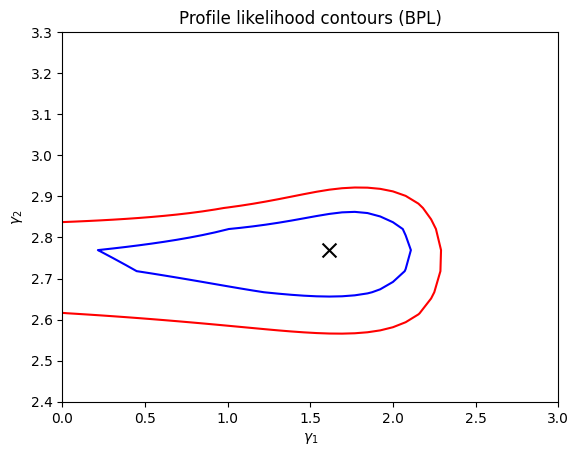

In [19]:
si1_grid = np.linspace(0, 3.0, 40)
si2_grid = np.linspace(2.0, 4.0, 40)

profile = np.zeros((len(si1_grid), len(si2_grid)))

for i, si1 in enumerate(si1_grid):
    for j, si2 in enumerate(si2_grid):
        def negloglike_free(params):
            norm, E_break = params
            return -loglike([norm, si1, si2, E_break],
                            y_obs, sigma1, sigma2, energy_edges_MESE)
        
        # maximize likelihood (minimize -logL) over free params
        res = minimize(negloglike_free, x0=[2.3, 4.5], bounds=[(1, 4), (4, 5)])
        profile[i, j] = -res.fun  # store the maximum logL for this (si1, si2)
    print(i)
    
Lmax = np.max(profile)
deltaNLL = -2 * (profile - Lmax)

best_fit_index = np.unravel_index(np.argmax(profile), profile.shape)
best_fit_si1 = si1_grid[best_fit_index[0]]
best_fit_si2 = si2_grid[best_fit_index[1]]
print(best_fit_si1, best_fit_si2)


plt.contour(si1_grid, si2_grid, deltaNLL.T,
            levels=[2.30, 6.18], colors=['blue','red'])
plt.scatter(best_fit_si1, best_fit_si2, color='black', marker='x', s=100)
plt.xlabel(r'$\gamma_1$')
plt.ylabel(r'$\gamma_2$')
plt.title("Profile likelihood contours (BPL)")
plt.ylim(2.4, 3.3)


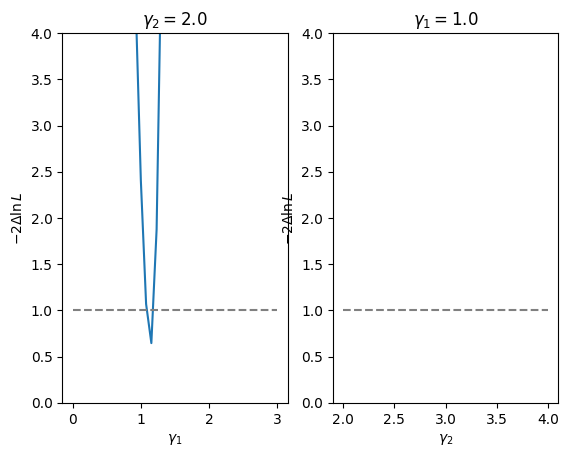

In [22]:
figure, axis = plt.subplots(1, 2)

axis[0].plot(si1_grid, deltaNLL[best_fit_index[1],:])
axis[0].plot(si1_grid, np.ones(len(si1_grid)), color='gray', linestyle='--')
axis[0].set_xlabel(r'$\gamma_1$')
axis[0].set_ylabel(r'$-2\Delta\ln L$')
axis[0].set_title(r'$\gamma_2 = 2.0$')
axis[0].set_ylim(0, 4)

axis[1].plot(si2_grid, deltaNLL[:,best_fit_index[0]])
axis[1].plot(si2_grid, np.ones(len(si2_grid)), color='gray', linestyle='--')
axis[1].set_xlabel(r'$\gamma_2$')
axis[1].set_ylabel(r'$-2\Delta\ln L$')
axis[1].set_title(r'$\gamma_1 = 1.0$')
axis[1].set_ylim(0, 4)

plt.show()



/tmp/ipykernel_82859/2025237670.py:72: RuntimeWarning: invalid value encountered in log
  ll = -0.5 * np.sum((y_obs - y_pred)**2 / y_err**2) - np.sum(np.log(y_err))


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
4.0 1.1


Text(0.5, 1.0, 'Profile likelihood contours (BPL)')

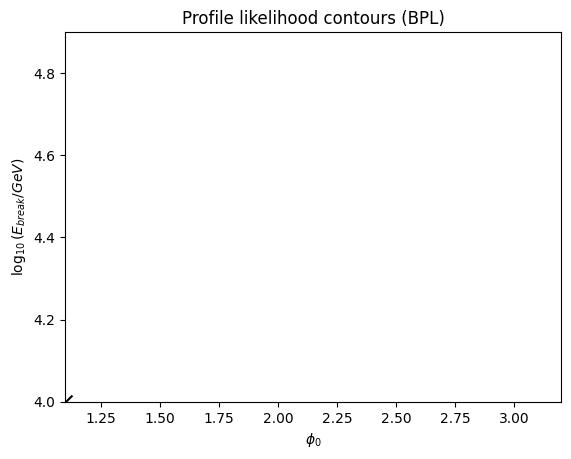

In [31]:
E_break_grid = np.linspace(4, 4.9, 40)
norm_grid = np.linspace(1.1, 3.2, 40)

profile = np.zeros((len(E_break_grid), len(norm_grid)))

for i, E_break in enumerate(E_break_grid):
    for j, norm in enumerate(norm_grid):
        def negloglike_free(params):
            si1, si2 = params
            return -loglike([norm, si1, si2, E_break],
                            y_obs, sigma1, sigma2, energy_edges_MESE)
        
        # maximize likelihood (minimize -logL) over free params
        res = minimize(negloglike_free, x0=[1.5, 3.0], bounds=[(0, 3), (2.4, 3.3)])
        profile[i, j] = -res.fun  # store the maximum logL for this (si1, si2)
    print(i)
    
Lmax = np.max(profile)
deltaNLL = -2 * (profile - Lmax)

best_fit_index = np.unravel_index(np.argmax(profile), profile.shape)
best_fit_E_break = E_break_grid[best_fit_index[0]]
best_fit_norm = norm_grid[best_fit_index[1]]
print(best_fit_E_break, best_fit_norm)


plt.contour(norm_grid, E_break_grid, deltaNLL,
            levels=[3, 7], colors=['blue','red'])
plt.scatter(best_fit_norm, best_fit_E_break, color='black', marker='x', s=100)
plt.xlabel(r'$\phi_0$')
plt.ylabel(r'$\log_{10}(E_{break}/GeV)$')
plt.title("Profile likelihood contours (BPL)")


In [32]:
print(profile)

[[          nan           nan           nan ... -311.11717634
  -312.13513129 -313.1783649 ]
 [          nan           nan           nan ... -310.77404457
  -311.79001789 -312.83116004]
 [          nan           nan           nan ... -310.34655287
  -311.35907858 -312.39664429]
 ...
 [          nan           nan           nan ...           nan
            nan           nan]
 [          nan           nan           nan ...           nan
            nan -296.65066301]
 [          nan           nan           nan ... -296.80402953
            nan           nan]]


In [ ]:
E_break_grid = np.linspace(4, 5, 40)
norm_grid = np.linspace(1.0, 4.0, 40)

profile = np.zeros((len(E_break_grid), len(norm_grid)))

for i, E_break in enumerate(E_break_grid):
    for j, norm in enumerate(norm_grid):
        def negloglike_free(params):
            si1, si2 = params
            return -loglike([norm, si1, si2, E_break],
                            y_obs, sigma1, sigma2, energy_edges_MESE)
        
        # maximize likelihood (minimize -logL) over free params
        res = minimize(negloglike_free, x0=[1.5, 3.0], bounds=[(0, 3), (2, 4)])
        profile[i, j] = -res.fun  # store the maximum logL for this (si1, si2)
    print(i)
    
Lmax = np.max(profile)
deltaNLL = -2 * (profile - Lmax)

best_fit_index = np.unravel_index(np.argmax(profile), profile.shape)
best_fit_E_break = E_break_grid[best_fit_index[0]]
best_fit_norm = norm_grid[best_fit_index[1]]
print(best_fit_E_break, best_fit_norm)


plt.contour(E_break_grid, norm_grid, deltaNLL.T,
            levels=[2.30, 6.18], colors=['blue','red'])
plt.scatter(best_fit_E_break, best_fit_norm, color='black', marker='x', s=100)
plt.xlabel(r'$\log_{10}(E_{break}/GeV)$')
plt.ylabel(r'$\phi_0$')
plt.title("Profile likelihood contours (BPL)")